# Percobaan Pengaruh Banyak Cell RNN per Layer

#### Import Dataset

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, Embedding, Bidirectional, SimpleRNN, Dropout, Dense
from tensorflow.keras import Sequential, Input
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Seeding

In [2]:
import random
import os

# Atur seed
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
tf.keras.utils.set_random_seed(seed_value)
tf.config.experimental.enable_op_determinism()
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '42'

#### Load Dataset

In [3]:
# Pemetaan label ke angka
label_mapping = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

# Load Dataset NusaX-Sentiment
# Train dataset
df_train = pd.read_csv("../../datasets/indonesian/train.csv")
train_texts = df_train['text'].astype(str).tolist()
df_train['label'] = df_train['label'].map(label_mapping) # Pemetaan label ke angka
train_labels = df_train['label'].astype(int).tolist()

# Validation dataset
df_val = pd.read_csv("../../datasets/indonesian/valid.csv")
val_texts = df_val['text'].astype(str).tolist()
df_val['label'] = df_val['label'].map(label_mapping) # Pemetaan label ke angka
val_labels = df_val['label'].astype(int).tolist()

# Test dataset
df_test = pd.read_csv("../../datasets/indonesian/test.csv")
test_texts = df_test['text'].astype(str).tolist()
df_test['label'] = df_test['label'].map(label_mapping) # Pemetaan label ke angka
test_labels = df_test['label'].astype(int).tolist()

#### Preprocessing - Tokenization & Vectorization

In [4]:
# Split data
X_train, X_val, X_test, y_train, y_val, y_test = train_texts, val_texts, test_texts, train_labels, val_labels, test_labels

# TextVectorization (Tokenization)
MAX_TOKENS = 10000      # Jumlah maksimum kata unik
MAX_LEN = 100           # Panjang maksimum sequence

vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode='int',
    output_sequence_length=MAX_LEN,
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    pad_to_max_tokens=True,
    ngrams=None,
)
vectorizer.adapt(X_train)

In [5]:
# 4. Dataset pipeline
def prepare_dataset(X, y):
    X_vec = vectorizer(tf.constant(X))
    return tf.data.Dataset.from_tensor_slices((X_vec, y)).batch(32).prefetch(tf.data.AUTOTUNE)

train_ds = prepare_dataset(X_train, y_train)
val_ds = prepare_dataset(X_val, y_val)
test_ds = prepare_dataset(X_test, y_test)

In [6]:
EMBED_DIM = 128

## Model 1: 32 Cell per Layer RNN

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.4185 - loss: 1.0804 - val_accuracy: 0.5200 - val_loss: 0.9860
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6338 - loss: 0.8640 - val_accuracy: 0.5200 - val_loss: 0.9840
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7770 - loss: 0.6796 - val_accuracy: 0.5100 - val_loss: 1.0177
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8591 - loss: 0.6008 - val_accuracy: 0.5500 - val_loss: 0.9044
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9722 - loss: 0.3380 - val_accuracy: 0.5400 - val_loss: 0.9607
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9814 - loss: 0.2156 - val_accuracy: 0.5200 - val_loss: 0.9854
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9987 - loss: 0.1197 - val_accuracy: 0.5100 - val_loss: 1.0256
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9973 - loss: 0.1154 - val_accuracy: 0.5200 - v

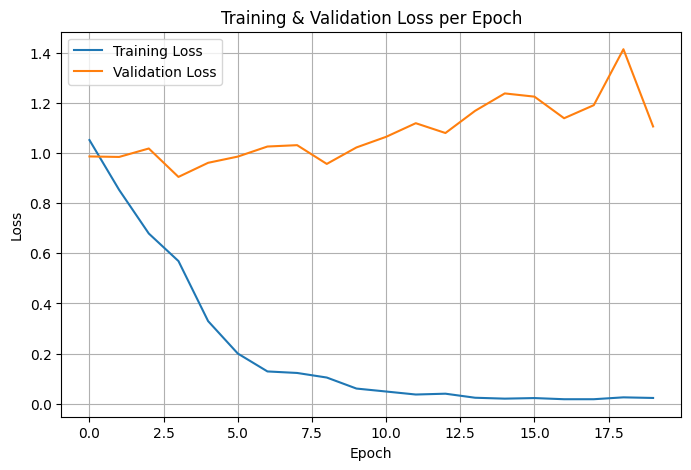

In [7]:
model1 = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_TOKENS, output_dim=EMBED_DIM),
    Bidirectional(SimpleRNN(32)),
    Dropout(0.5),
    Dense(3, activation='softmax')
])


model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    batch_size=32
)

# Prediksi di test set
predictions = model1.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Hitung macro F1-Score
from sklearn.metrics import f1_score
macro_f1 = f1_score(test_labels, predicted_labels, average='macro')
print(f"Macro F1-Score: {macro_f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model 2: 64 Cell per Layer RNN

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.3993 - loss: 1.0549 - val_accuracy: 0.5300 - val_loss: 1.0023
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6648 - loss: 0.8266 - val_accuracy: 0.5100 - val_loss: 0.9786
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8097 - loss: 0.5888 - val_accuracy: 0.5400 - val_loss: 0.9593
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8908 - loss: 0.3829 - val_accuracy: 0.5100 - val_loss: 0.9575
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9549 - loss: 0.2669 - val_accuracy: 0.5400 - val_loss: 0.9771
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9980 - loss: 0.1470 - val_accuracy: 0.5200 - val_loss: 0.9519
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9912 - loss: 0.0834 - val_accuracy: 0.5600 - val_loss: 0.9491
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 1.0000 - loss: 0.0446 - val_accuracy: 0.5500 - v

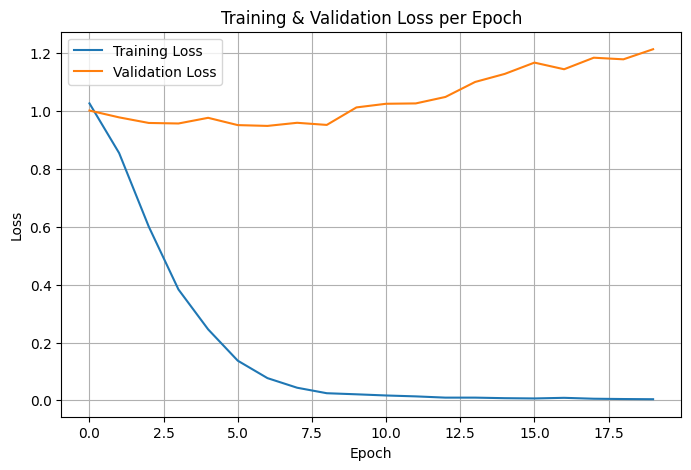

In [8]:
model2 = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_TOKENS, output_dim=EMBED_DIM),
    Bidirectional(SimpleRNN(64)),
    Dropout(0.5),
    Dense(3, activation='softmax')
])


model2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    batch_size=32
)

# Prediksi di test set
predictions = model2.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Hitung macro F1-Score
from sklearn.metrics import f1_score
macro_f1 = f1_score(test_labels, predicted_labels, average='macro')
print(f"Macro F1-Score: {macro_f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model 3: 128 Cell per Layer RNN

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.4086 - loss: 1.0801 - val_accuracy: 0.4300 - val_loss: 1.1060
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5849 - loss: 0.8465 - val_accuracy: 0.4800 - val_loss: 0.9948
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8275 - loss: 0.5453 - val_accuracy: 0.4400 - val_loss: 1.1227
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9163 - loss: 0.3014 - val_accuracy: 0.3800 - val_loss: 1.7185
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8437 - loss: 0.3580 - val_accuracy: 0.4200 - val_loss: 1.1998
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9445 - loss: 0.2099 - val_accuracy: 0.4800 - val_loss: 1.1443
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9868 - loss: 0.0797 - val_accuracy: 0.5100 - val_loss: 1.2355
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9917 - loss: 0.0484 - val_accuracy: 0.5100 - v

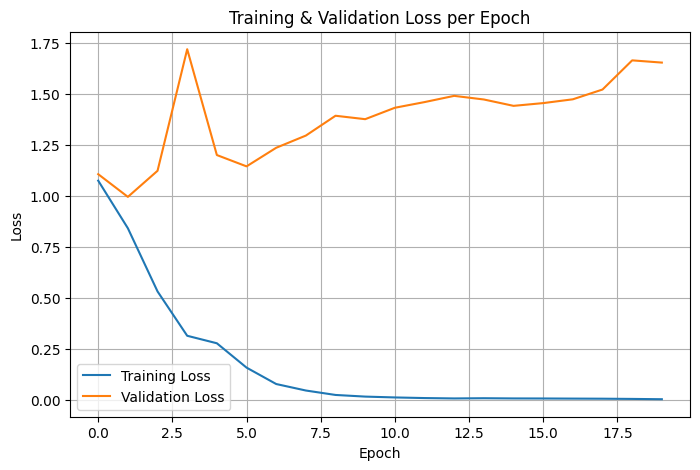

In [9]:
model3 = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_TOKENS, output_dim=EMBED_DIM),
    Bidirectional(SimpleRNN(128)),
    Dropout(0.5),
    Dense(3, activation='softmax')
])


model3.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    batch_size=32
)

# Prediksi di test set
predictions = model3.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Hitung macro F1-Score
from sklearn.metrics import f1_score
macro_f1 = f1_score(test_labels, predicted_labels, average='macro')
print(f"Macro F1-Score: {macro_f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()